# Module 2 — Risk & VaR Model
**Zaeem Hasan | Quant Portfolio Study**

Picks up directly from Module 1 exports.

**Three VaR methods, same as Saunders Ch. 15:**
1. **Historical Simulation** — use actual past return distribution, no assumptions
2. **Parametric (Variance-Covariance)** — assume normal distribution, use σ
3. **Monte Carlo** — simulate thousands of possible futures from estimated parameters

**Also computed:**
- CVaR / Expected Shortfall (what you lose *given* you breach VaR)
- Rolling 30-day VaR over time
- Correlation matrix across all positions
- Beta vs SPY per ticker
- Sharpe, Sortino, Treynor ratios


In [32]:
# ── 0. Dependencies ──────────────────────────────────────────────────────────
!pip install yfinance pandas numpy matplotlib seaborn scipy --quiet


from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
# ── 1. Imports ───────────────────────────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from datetime import date
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f9f9f9',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'axes.spines.top':  False,
    'axes.spines.right':False
})
print('Libraries loaded.')

Libraries loaded.


In [46]:
# ── 2. Load data from Module 1 ───────────────────────────────────────────────
# Option A: load from CSVs exported by Module 1 (preferred)
# Option B: re-pull from yfinance if CSVs aren't available

TICKERS = ['LITE','AMD','COHR','GOOG','MRVL','GLD','VRT','EQIX','AVGO','SNDR','ANET']
START   = '2025-08-08'
END     = date.today().strftime('%Y-%m-%d')

DRIVE_PATH = '/content/drive/MyDrive/quant-project/'

try:
    prices     = pd.read_csv(DRIVE_PATH + 'module1_prices.csv',  index_col=0, parse_dates=True)
    returns_df = pd.read_csv(DRIVE_PATH + 'module1_returns.csv', index_col=0, parse_dates=True)
    print('Loaded from Module 1 CSVs.')
except FileNotFoundError:
    ...
    print('Module 1 CSVs not found — re-pulling from yfinance...')
    raw     = yf.download(TICKERS + ['SPY'], start=START, end=END,
                          auto_adjust=True, progress=False)
    prices  = raw['Close'][TICKERS].copy()
    spy_ret = raw['Close']['SPY'].pct_change().dropna()
    # Equal-weight portfolio returns as fallback
    port_ret = prices.pct_change().dropna().mean(axis=1)
    returns_df = pd.DataFrame({'portfolio': port_ret, 'spy': spy_ret})
    print('Re-pulled successfully.')

# Individual ticker daily returns
ticker_returns = prices.pct_change().dropna()

port_ret = returns_df['portfolio']
spy_ret  = returns_df['spy']

print(f'\nReturn series length: {len(port_ret)} trading days')
print(f'Date range: {port_ret.index[0].date()} → {port_ret.index[-1].date()}')

Loaded from Module 1 CSVs.

Return series length: 165 trading days
Date range: 2025-08-11 → 2026-04-07


In [35]:
# ── 3. Parameters ────────────────────────────────────────────────────────────
PORTFOLIO_VALUE = 123.00   # Update this to your current portfolio value from Module 1
CONFIDENCE      = 0.95     # 95% confidence — standard (Saunders uses this)
CONFIDENCE_99   = 0.99     # 99% for comparison
RISK_FREE       = 0.045    # 4.5% annual risk-free rate
TRADING_DAYS    = 252

print(f'Portfolio value:    ${PORTFOLIO_VALUE:.2f}')
print(f'VaR confidence:     {CONFIDENCE:.0%} and {CONFIDENCE_99:.0%}')
print(f'Risk-free rate:     {RISK_FREE:.1%}')

Portfolio value:    $123.00
VaR confidence:     95% and 99%
Risk-free rate:     4.5%


In [36]:
# ── 4. Method 1: Historical Simulation VaR ───────────────────────────────────
# Sort the actual past returns. The 5th percentile IS your VaR.
# No distribution assumption — the data speaks for itself.

var_hist_95 = np.percentile(port_ret, (1 - CONFIDENCE)  * 100)
var_hist_99 = np.percentile(port_ret, (1 - CONFIDENCE_99) * 100)

# CVaR = Expected Shortfall: mean of all returns WORSE than VaR
cvar_hist_95 = port_ret[port_ret <= var_hist_95].mean()
cvar_hist_99 = port_ret[port_ret <= var_hist_99].mean()

# Dollar amounts
var_hist_95_dollar  = PORTFOLIO_VALUE * var_hist_95
var_hist_99_dollar  = PORTFOLIO_VALUE * var_hist_99
cvar_hist_95_dollar = PORTFOLIO_VALUE * cvar_hist_95

print('── Historical Simulation ──────────────────────────────')
print(f'  VaR  95%: {var_hist_95:.2%}  →  ${var_hist_95_dollar:.2f}')
print(f'  VaR  99%: {var_hist_99:.2%}  →  ${var_hist_99_dollar:.2f}')
print(f'  CVaR 95%: {cvar_hist_95:.2%}  →  ${cvar_hist_95_dollar:.2f}')
print()
print('Interpretation:')
print(f'  On any given day, there is a 5% chance you lose more than ${abs(var_hist_95_dollar):.2f}.')
print(f'  When you do breach that threshold, the average loss is ${abs(cvar_hist_95_dollar):.2f} (CVaR).')

── Historical Simulation ──────────────────────────────
  VaR  95%: -3.37%  →  $-4.14
  VaR  99%: -4.79%  →  $-5.90
  CVaR 95%: -4.23%  →  $-5.20

Interpretation:
  On any given day, there is a 5% chance you lose more than $4.14.
  When you do breach that threshold, the average loss is $5.20 (CVaR).


In [37]:
# ── 5. Method 2: Parametric VaR (Variance-Covariance) ────────────────────────
# Assume returns are normally distributed.
# VaR = μ - z * σ
# This is the DEAR method from Saunders — Daily Earnings at Risk.

mu    = port_ret.mean()   # daily mean return
sigma = port_ret.std()    # daily standard deviation

z_95 = stats.norm.ppf(1 - CONFIDENCE)    # -1.645
z_99 = stats.norm.ppf(1 - CONFIDENCE_99) # -2.326

var_param_95 = mu + z_95 * sigma
var_param_99 = mu + z_99 * sigma

# CVaR under normality: -φ(z)/α * σ + μ
cvar_param_95 = mu - sigma * stats.norm.pdf(z_95) / (1 - CONFIDENCE)

var_param_95_dollar  = PORTFOLIO_VALUE * var_param_95
var_param_99_dollar  = PORTFOLIO_VALUE * var_param_99
cvar_param_95_dollar = PORTFOLIO_VALUE * cvar_param_95

print('── Parametric (Variance-Covariance) ───────────────────')
print(f'  Daily μ:   {mu:.4%}')
print(f'  Daily σ:   {sigma:.4%}')
print(f'  Ann. σ:    {sigma * np.sqrt(TRADING_DAYS):.2%}')
print(f'  VaR  95%: {var_param_95:.2%}  →  ${var_param_95_dollar:.2f}')
print(f'  VaR  99%: {var_param_99:.2%}  →  ${var_param_99_dollar:.2f}')
print(f'  CVaR 95%: {cvar_param_95:.2%}  →  ${cvar_param_95_dollar:.2f}')
print()
print('Note: parametric VaR underestimates tail risk for skewed / fat-tailed portfolios.')
print('Compare with historical — if historical VaR is worse, your returns have fat tails.')

── Parametric (Variance-Covariance) ───────────────────
  Daily μ:   0.3474%
  Daily σ:   2.0705%
  Ann. σ:    32.87%
  VaR  95%: -3.06%  →  $-3.76
  VaR  99%: -4.47%  →  $-5.50
  CVaR 95%: -3.92%  →  $-4.83

Note: parametric VaR underestimates tail risk for skewed / fat-tailed portfolios.
Compare with historical — if historical VaR is worse, your returns have fat tails.


In [38]:
# ── 6. Method 3: Monte Carlo VaR ─────────────────────────────────────────────
# Simulate 10,000 possible single-day returns using estimated μ and σ.
# More flexible than parametric — can plug in non-normal distributions later.

N_SIMS = 10_000
np.random.seed(42)

simulated_returns = np.random.normal(loc=mu, scale=sigma, size=N_SIMS)

var_mc_95 = np.percentile(simulated_returns, (1 - CONFIDENCE) * 100)
var_mc_99 = np.percentile(simulated_returns, (1 - CONFIDENCE_99) * 100)
cvar_mc_95 = simulated_returns[simulated_returns <= var_mc_95].mean()

var_mc_95_dollar  = PORTFOLIO_VALUE * var_mc_95
var_mc_99_dollar  = PORTFOLIO_VALUE * var_mc_99
cvar_mc_95_dollar = PORTFOLIO_VALUE * cvar_mc_95

print('── Monte Carlo (10,000 simulations) ───────────────────')
print(f'  VaR  95%: {var_mc_95:.2%}  →  ${var_mc_95_dollar:.2f}')
print(f'  VaR  99%: {var_mc_99:.2%}  →  ${var_mc_99_dollar:.2f}')
print(f'  CVaR 95%: {cvar_mc_95:.2%}  →  ${cvar_mc_95_dollar:.2f}')

── Monte Carlo (10,000 simulations) ───────────────────
  VaR  95%: -3.08%  →  $-3.79
  VaR  99%: -4.46%  →  $-5.48
  CVaR 95%: -3.95%  →  $-4.86


In [39]:
# ── 7. VaR comparison summary ─────────────────────────────────────────────────
var_summary = pd.DataFrame({
    'Method':        ['Historical', 'Parametric', 'Monte Carlo'],
    'VaR 95% (%)':   [f'{var_hist_95:.2%}',  f'{var_param_95:.2%}',  f'{var_mc_95:.2%}'],
    'VaR 95% ($)':   [f'${var_hist_95_dollar:.2f}',  f'${var_param_95_dollar:.2f}',  f'${var_mc_95_dollar:.2f}'],
    'VaR 99% ($)':   [f'${var_hist_99_dollar:.2f}',  f'${var_param_99_dollar:.2f}',  f'${var_mc_99_dollar:.2f}'],
    'CVaR 95% ($)':  [f'${cvar_hist_95_dollar:.2f}', f'${cvar_param_95_dollar:.2f}', f'${cvar_mc_95_dollar:.2f}'],
})
print(var_summary.to_string(index=False))

     Method VaR 95% (%) VaR 95% ($) VaR 99% ($) CVaR 95% ($)
 Historical      -3.37%      $-4.14      $-5.90       $-5.20
 Parametric      -3.06%      $-3.76      $-5.50       $-4.83
Monte Carlo      -3.08%      $-3.79      $-5.48       $-4.86


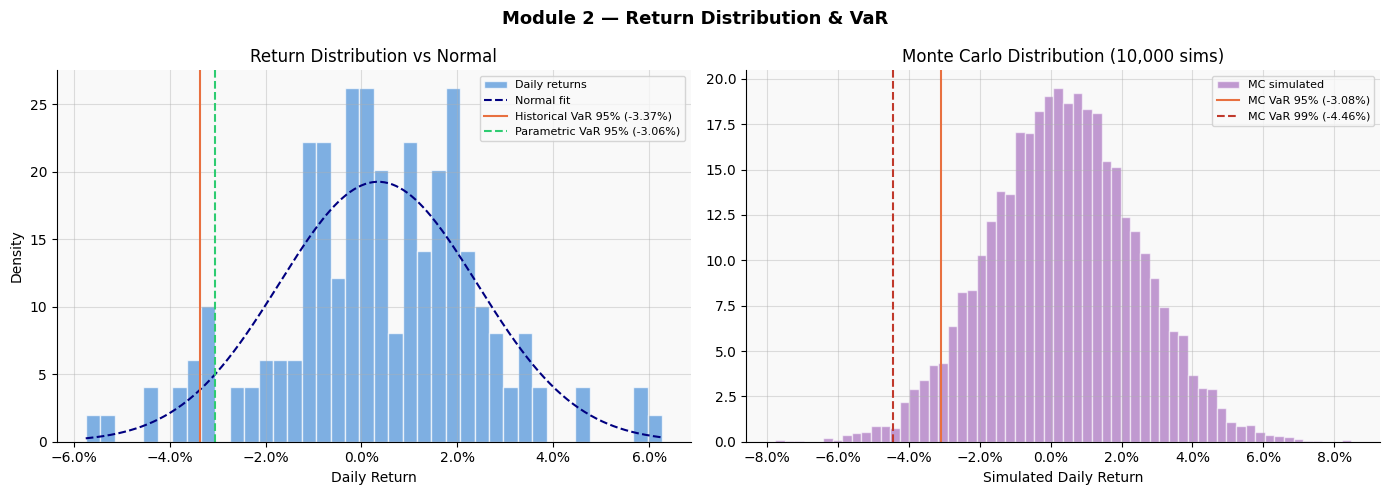

In [40]:
# ── 8. Plot: Return distribution + VaR lines ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Module 2 — Return Distribution & VaR', fontsize=13, fontweight='bold')

# Left: histogram of actual daily returns with VaR lines
ax1 = axes[0]
ax1.hist(port_ret, bins=40, color='#4A90D9', alpha=0.7, edgecolor='white', density=True, label='Daily returns')

# Overlay normal fit
x = np.linspace(port_ret.min(), port_ret.max(), 300)
ax1.plot(x, stats.norm.pdf(x, mu, sigma), color='navy', linewidth=1.5, linestyle='--', label='Normal fit')

ax1.axvline(var_hist_95,  color='#E87040', linewidth=1.5, label=f'Historical VaR 95% ({var_hist_95:.2%})')
ax1.axvline(var_param_95, color='#2ecc71', linewidth=1.5, linestyle='--', label=f'Parametric VaR 95% ({var_param_95:.2%})')
ax1.set_xlabel('Daily Return')
ax1.set_ylabel('Density')
ax1.set_title('Return Distribution vs Normal')
ax1.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax1.legend(fontsize=8)

# Right: Monte Carlo simulation distribution
ax2 = axes[1]
ax2.hist(simulated_returns, bins=60, color='#9B59B6', alpha=0.6, edgecolor='white', density=True, label='MC simulated')
ax2.axvline(var_mc_95, color='#E87040', linewidth=1.5, label=f'MC VaR 95% ({var_mc_95:.2%})')
ax2.axvline(var_mc_99, color='#c0392b', linewidth=1.5, linestyle='--', label=f'MC VaR 99% ({var_mc_99:.2%})')
ax2.set_xlabel('Simulated Daily Return')
ax2.set_title('Monte Carlo Distribution (10,000 sims)')
ax2.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('module2_var_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

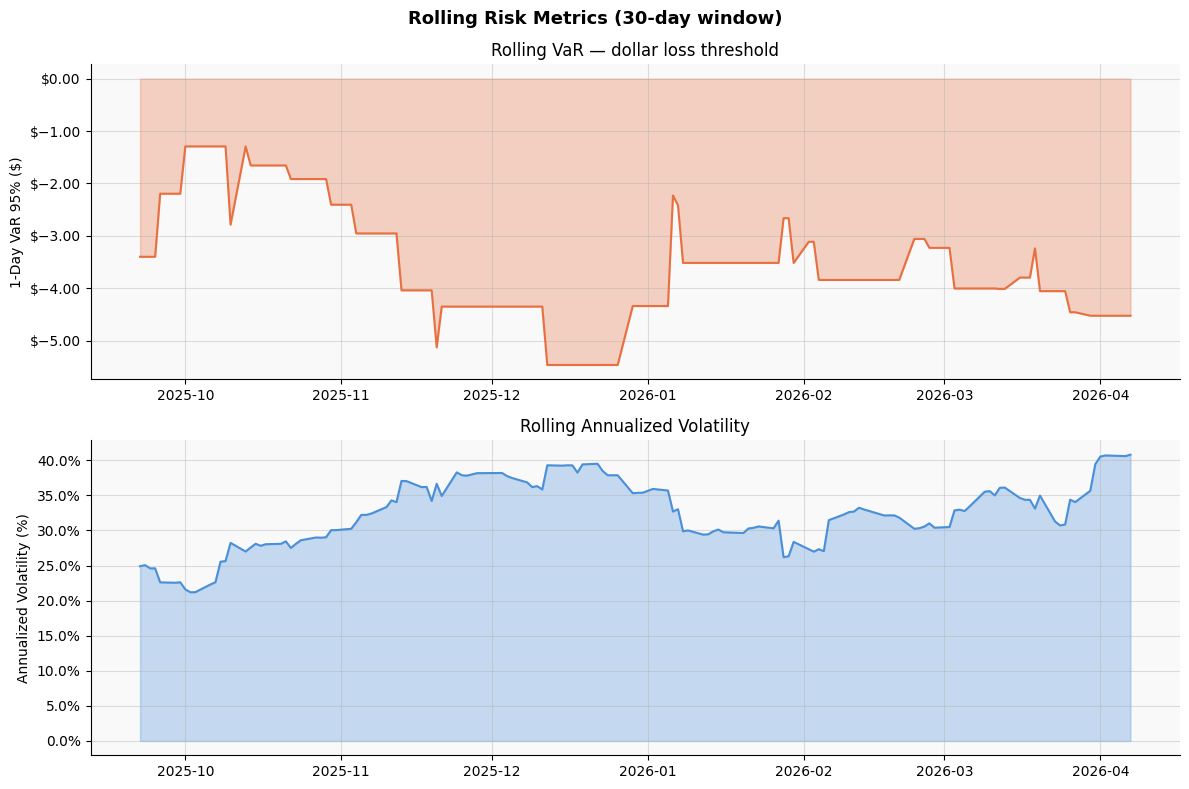

In [41]:
# ── 9. Rolling 30-day VaR ────────────────────────────────────────────────────
# VaR is not static — it changes as volatility regimes shift.
# This shows how your risk profile evolved over the holding period.

WINDOW = 30
rolling_var = port_ret.rolling(WINDOW).quantile(1 - CONFIDENCE)
rolling_vol = port_ret.rolling(WINDOW).std() * np.sqrt(TRADING_DAYS)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle('Rolling Risk Metrics (30-day window)', fontsize=13, fontweight='bold')

ax1 = axes[0]
ax1.plot(rolling_var.index, rolling_var * PORTFOLIO_VALUE, color='#E87040', linewidth=1.5)
ax1.fill_between(rolling_var.index, rolling_var * PORTFOLIO_VALUE, 0, alpha=0.3, color='#E87040')
ax1.set_ylabel('1-Day VaR 95% ($)')
ax1.set_title('Rolling VaR — dollar loss threshold')
ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.2f}'))

ax2 = axes[1]
ax2.plot(rolling_vol.index, rolling_vol * 100, color='#4A90D9', linewidth=1.5)
ax2.fill_between(rolling_vol.index, rolling_vol * 100, 0, alpha=0.3, color='#4A90D9')
ax2.set_ylabel('Annualized Volatility (%)')
ax2.set_title('Rolling Annualized Volatility')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig('module2_rolling_risk.png', dpi=150, bbox_inches='tight')
plt.show()

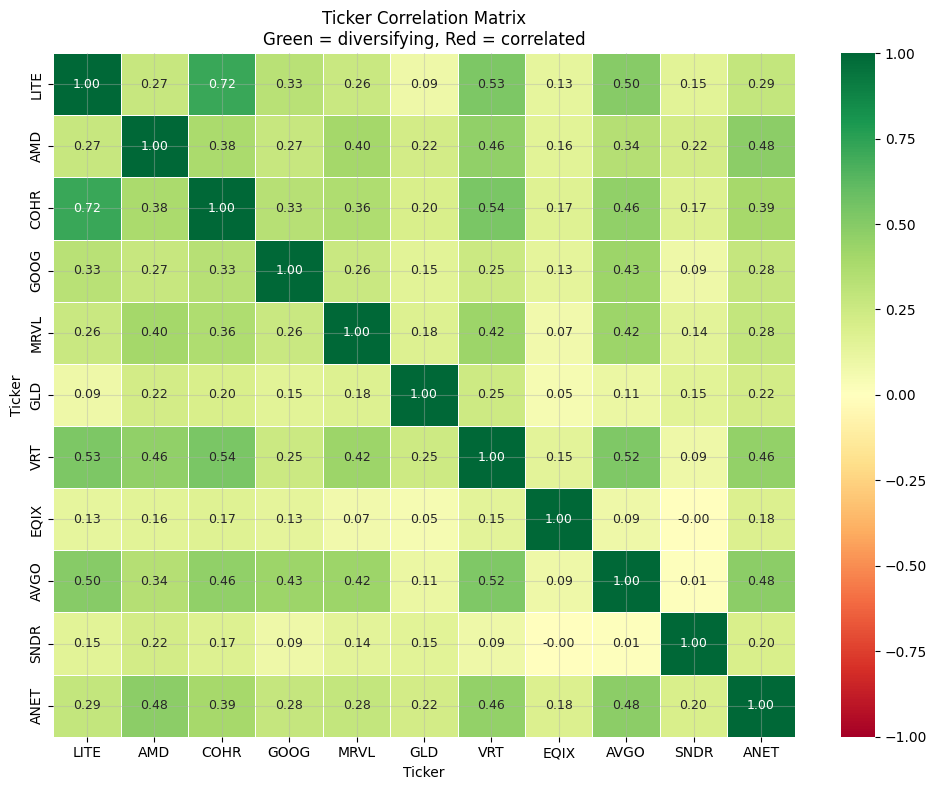


Highly correlated pairs (|r| > 0.70):
  LITE ↔ COHR: 0.72


In [42]:
# ── 10. Correlation matrix ───────────────────────────────────────────────────
# Low correlation = diversification benefit.
# High correlation = concentrated risk even if tickers look different.

corr = ticker_returns.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # upper triangle only
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Ticker Correlation Matrix\nGreen = diversifying, Red = correlated', fontsize=12)
plt.tight_layout()
plt.savefig('module2_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag highly correlated pairs
print('\nHighly correlated pairs (|r| > 0.70):')
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.70:
            print(f'  {corr.columns[i]} ↔ {corr.columns[j]}: {r:.2f}')

In [43]:
# ── 11. Beta vs SPY + risk-adjusted ratios ───────────────────────────────────
# Beta = how much your portfolio moves per 1% SPY move
# Sharpe  = excess return per unit of total risk
# Sortino = excess return per unit of DOWNSIDE risk only
# Treynor = excess return per unit of MARKET risk (beta)

aligned = pd.concat([port_ret, spy_ret], axis=1).dropna()
aligned.columns = ['portfolio', 'spy']

# Beta via OLS
cov_matrix = aligned.cov()
beta = cov_matrix.loc['portfolio', 'spy'] / aligned['spy'].var()
alpha_daily = aligned['portfolio'].mean() - beta * aligned['spy'].mean()
alpha_ann   = alpha_daily * TRADING_DAYS

# Ratios
ann_ret = port_ret.mean() * TRADING_DAYS
ann_vol = port_ret.std()  * np.sqrt(TRADING_DAYS)
excess_ret = ann_ret - RISK_FREE

sharpe  = excess_ret / ann_vol

downside_ret = port_ret[port_ret < 0]
downside_vol = downside_ret.std() * np.sqrt(TRADING_DAYS)
sortino = excess_ret / downside_vol

treynor = excess_ret / beta

print('── Beta & Risk-Adjusted Ratios ────────────────────────')
print(f'  Portfolio Beta (vs SPY): {beta:.3f}')
print(f'  Alpha (annualized):      {alpha_ann:.2%}')
print(f'  Annual Return:           {ann_ret:.2%}')
print(f'  Annual Volatility:       {ann_vol:.2%}')
print(f'  Sharpe Ratio:            {sharpe:.3f}')
print(f'  Sortino Ratio:           {sortino:.3f}')
print(f'  Treynor Ratio:           {treynor:.4f}')
print()
print('Interpretation:')
print(f'  Beta > 1 means your portfolio amplifies SPY moves. Beta = {beta:.2f}')
print(f'  Positive alpha ({alpha_ann:.2%}) = returns above what beta alone explains.')
print(f'  Sharpe > 1.0 is generally considered good. Yours: {sharpe:.2f}')

── Beta & Risk-Adjusted Ratios ────────────────────────
  Portfolio Beta (vs SPY): 1.948
  Alpha (annualized):      73.44%
  Annual Return:           87.55%
  Annual Volatility:       32.87%
  Sharpe Ratio:            2.527
  Sortino Ratio:           3.784
  Treynor Ratio:           0.4263

Interpretation:
  Beta > 1 means your portfolio amplifies SPY moves. Beta = 1.95
  Positive alpha (73.44%) = returns above what beta alone explains.
  Sharpe > 1.0 is generally considered good. Yours: 2.53


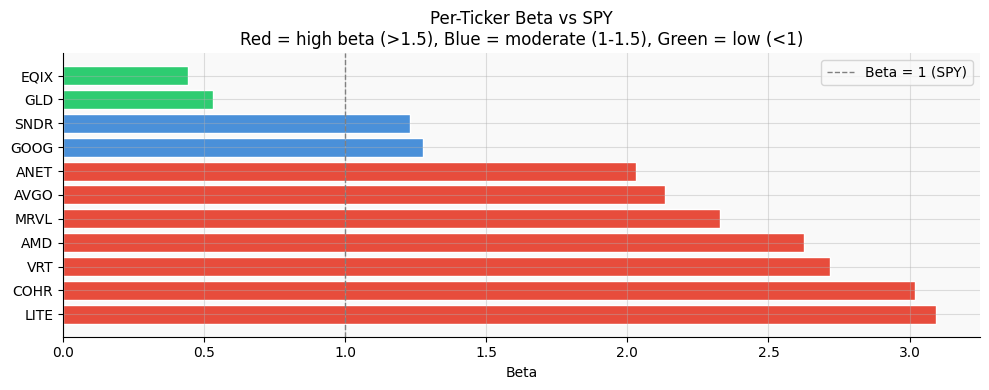

          Beta
LITE  3.094767
COHR  3.018417
VRT   2.716247
AMD   2.626684
MRVL  2.329785
AVGO  2.131728
ANET  2.031377
GOOG  1.275945
SNDR  1.227950
GLD   0.531111
EQIX  0.443735


In [44]:
# ── 12. Per-ticker beta ──────────────────────────────────────────────────────
ticker_betas = {}
for t in TICKERS:
    if t not in ticker_returns.columns:
        continue
    aligned_t = pd.concat([ticker_returns[t], spy_ret], axis=1).dropna()
    aligned_t.columns = [t, 'spy']
    cov_t = aligned_t.cov()
    ticker_betas[t] = cov_t.loc[t, 'spy'] / aligned_t['spy'].var()

beta_df = pd.DataFrame.from_dict(ticker_betas, orient='index', columns=['Beta'])
beta_df = beta_df.sort_values('Beta', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if b > 1.5 else '#4A90D9' if b > 1.0 else '#2ecc71' for b in beta_df['Beta']]
ax.barh(beta_df.index, beta_df['Beta'], color=colors, edgecolor='white')
ax.axvline(1.0, color='gray', linewidth=1, linestyle='--', label='Beta = 1 (SPY)')
ax.set_xlabel('Beta')
ax.set_title('Per-Ticker Beta vs SPY\nRed = high beta (>1.5), Blue = moderate (1-1.5), Green = low (<1)')
ax.legend()
plt.tight_layout()
plt.savefig('module2_betas.png', dpi=150, bbox_inches='tight')
plt.show()
print(beta_df.to_string())

In [45]:
# ── 13. Export for Module 3 & 5 ─────────────────────────────────────────────
risk_summary = pd.DataFrame({
    'Metric': [
        'VaR 95% Historical', 'VaR 99% Historical',
        'VaR 95% Parametric', 'VaR 99% Parametric',
        'CVaR 95% Historical',
        'Portfolio Beta', 'Alpha (ann.)',
        'Sharpe Ratio', 'Sortino Ratio', 'Treynor Ratio',
        'Ann. Volatility', 'Ann. Return'
    ],
    'Value': [
        f'{var_hist_95:.4f}',  f'{var_hist_99:.4f}',
        f'{var_param_95:.4f}', f'{var_param_99:.4f}',
        f'{cvar_hist_95:.4f}',
        f'{beta:.4f}', f'{alpha_ann:.4f}',
        f'{sharpe:.4f}', f'{sortino:.4f}', f'{treynor:.4f}',
        f'{ann_vol:.4f}', f'{ann_ret:.4f}'
    ]
})

risk_summary.to_csv(DRIVE_PATH + 'module2_risk_summary.csv', index=False)
beta_df.to_csv(DRIVE_PATH + 'module2_betas.csv')
ticker_returns.to_csv(DRIVE_PATH + 'module2_ticker_returns.csv')

print('Exported:')
print('  module2_risk_summary.csv    — all VaR + ratio metrics')
print('  module2_betas.csv           — per-ticker beta')
print('  module2_ticker_returns.csv  — individual return series')
print()
print('Ready for Module 3 (Live Signals) and Module 5 (Investment Memo).')

Exported:
  module2_risk_summary.csv    — all VaR + ratio metrics
  module2_betas.csv           — per-ticker beta
  module2_ticker_returns.csv  — individual return series

Ready for Module 3 (Live Signals) and Module 5 (Investment Memo).
